# Ejercicio 2 (sesión 6): reformado de propano con vapor — versión reporte

Versión "reporte" de `ejercicios/ej2_mio.py`: **importa el solver desde `core`** (no copia
la lógica), agrega la derivación en Markdown, muestra los resultados como tablas y gráfica,
y termina llamando a `selfcheck`. Los números son los mismos que el script canónico.

## Enunciado

Alimentación: 1 mol C₃H₈, 4 mol H₂O, 0.5 mol N₂ (inerte). P = 1 bar. Se dan las
constantes de equilibrio (forma en fracción mol) a 700, 900 y 1000 K.

| | Reacción | δ_j |
|---|---|---|
| R1 (reformado) | $\mathrm{C_3H_8 + 3\,H_2O \rightleftharpoons 3\,CO + 7\,H_2}$ | +6 |
| R2 (WGS) | $\mathrm{CO + H_2O \rightleftharpoons CO_2 + H_2}$ | 0 |
| R3 (metanación) | $\mathrm{C_3H_8 + 2\,H_2 \rightleftharpoons 3\,CH_4}$ | 0 |

## Derivación

Con avances ξ₁, ξ₂, ξ₃ y $n_i = n_{i0} + \sum_j \nu_{ij}\xi_j$:

$$n_{C_3H_8} = 1 - \xi_1 - \xi_3 \qquad n_{H_2O} = 4 - 3\xi_1 - \xi_2 \qquad n_{CO} = 3\xi_1 - \xi_2$$
$$n_{H_2} = 7\xi_1 + \xi_2 - 2\xi_3 \qquad n_{CO_2} = \xi_2 \qquad n_{CH_4} = 3\xi_3 \qquad n_{N_2} = 0.5$$
$$n_T = 5.5 + 6\,\xi_1$$

Las tres condiciones de equilibrio ($y_i = n_i/n_T$, $P/P^\circ = 1$):

$$K_1 = \frac{y_{CO}^3\, y_{H_2}^7}{y_{C_3H_8}\, y_{H_2O}^3}\left(\frac{P}{P^\circ}\right)^{6}, \qquad
K_2 = \frac{y_{CO_2}\, y_{H_2}}{y_{CO}\, y_{H_2O}}, \qquad
K_3 = \frac{y_{CH_4}^3}{y_{C_3H_8}\, y_{H_2}^2}$$

`core.equilibrium.solve_extents` resuelve el sistema en forma logarítmica (ver
`00_teoria.ipynb`, sección 5).

**Métricas pedidas:** conversión $X = (n_{C_3H_8,0} - n_{C_3H_8})/n_{C_3H_8,0} = \xi_1 + \xi_3$;
selectividades $S_i = n_i/(n_{CO} + n_{CO_2} + n_{CH_4})$; rendimiento $Y_{H_2} = n_{H_2}/10$
(10 mol de H₂ por mol de C₃H₈ si R1 y R2 fueran completas) y $Y_{H_2,\mathrm{alim}} = n_{H_2}/8$
(máximo con 4 mol de H₂O: R1 completa y la WGS con el mol de agua sobrante); razones
$\mathrm{H_2/CO}$ y $\mathrm{H_2/CO_x}$.

In [1]:
# Shim de sys.path: mismo que en los scripts (parents[1] + búsqueda de core/ hacia arriba)
import sys, pathlib
try:
    _RAIZ = pathlib.Path(__file__).resolve().parents[1]          # raíz del proyecto
except NameError:                                                # celda/notebook sin __file__
    _RAIZ = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
                  if (p / "core" / "exercise.py").exists()), None)
    if _RAIZ is None:
        raise RuntimeError("no encuentro core/ desde el cwd: corre el kernel "
                           "con la carpeta del notebook como directorio de trabajo")
sys.path.insert(0, str(_RAIZ))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from core.equilibrium import solve_extents
from core.selfcheck import Problem, validate, validate_sweep

## Datos del problema

Mismos inputs que `ejercicios/ej2_mio.py` (especies, alimentación, matriz ν, átomos y K por T).

In [2]:
especies = ["C3H8", "H2O", "CO", "H2", "CO2", "CH4", "N2"]
n0 = {"C3H8": 1.0, "H2O": 4.0, "CO": 0.0, "H2": 0.0, "CO2": 0.0, "CH4": 0.0, "N2": 0.5}
#          C3H8  H2O   CO   H2  CO2  CH4   N2
nu = [
    [  -1,  -3,   3,   7,   0,   0,   0 ],   # R1: reformado
    [   0,  -1,  -1,   1,   1,   0,   0 ],   # R2: WGS
    [  -1,   0,   0,  -2,   0,   3,   0 ],   # R3: metanación
]
atomos = {"C3H8": {"C": 3, "H": 8}, "H2O": {"H": 2, "O": 1}, "CO": {"C": 1, "O": 1},
          "H2": {"H": 2}, "CO2": {"C": 1, "O": 2}, "CH4": {"C": 1, "H": 4}, "N2": {"N": 2}}
casos = {                       # T: [K1, K2, K3]
    700:  [7.2285e-3, 7.5034,  2.4203e10],
    900:  [1.3407e6,  1.5591,  2.4864e8 ],
    1000: [1.0501e9,  0.89956, 5.0080e7 ],
}
P = 1.0   # bar
H2_MAX_TEORICO, H2_MAX_ALIMENTACION = 10.0, 8.0

pd.DataFrame(nu, index=["R1", "R2", "R3"], columns=especies).assign(δ=np.sum(nu, axis=1))

,C3H8,H2O,CO,H2,CO2,CH4,N2,δ
R1,-1,-3,3,7,0,0,0,6
R2,0,-1,-1,1,1,0,0,0
R3,-1,0,0,-2,0,3,0,0


## Solución: avances, moles y fracciones mol

In [3]:
resultados = {T: solve_extents(especies, n0, nu, K, P, atoms=atomos) for T, K in casos.items()}

filas = []
for T, res in resultados.items():
    fila = {"T (K)": T, **{f"xi_{j+1}": x for j, x in enumerate(res.xi)}, "n_T": res.n_total}
    fila.update({f"n_{sp}": res.moles[sp] for sp in especies})
    fila.update({f"y_{sp}": res.mole_fractions[sp] for sp in especies})
    filas.append(fila)
tabla = pd.DataFrame(filas).set_index("T (K)")
tabla.round(5)

,xi_1,xi_2,xi_3,n_T,n_C3H8,n_H2O,n_CO,n_H2,n_CO2,n_CH4,n_N2,y_C3H8,y_H2O,y_CO,y_H2,y_CO2,y_CH4,y_N2
T (K),,,,,,,,,,,,,,,,,,
700,0.24044,0.69089,0.75956,6.94262,0.0,2.58780,0.03042,0.85482,0.69089,2.27869,0.5,0.0,0.37274,0.00438,0.12313,0.09951,0.32822,0.07202
900,0.51885,0.69625,0.48115,8.61313,0.0,1.74719,0.86032,3.36594,0.69625,1.44344,0.5,0.0,0.20285,0.09988,0.39079,0.08084,0.16759,0.05805
1000,0.75718,0.41774,0.24282,10.04310,0.0,1.31071,1.85381,5.23239,0.41774,0.72845,0.5,0.0,0.13051,0.18459,0.52099,0.04159,0.07253,0.04979


## Conversión, selectividades y rendimiento de H₂

In [4]:
metricas = []
for T, res in resultados.items():
    n = res.moles
    xi1, xi2, xi3 = res.xi
    C_tot = n["CO"] + n["CO2"] + n["CH4"]
    metricas.append({
        "T (K)": T,
        "X_C3H8": (n0["C3H8"] - n["C3H8"]) / n0["C3H8"],
        "S_reformado": xi1 / (xi1 + xi3),
        "S_CO": n["CO"] / C_tot, "S_CO2": n["CO2"] / C_tot, "S_CH4": n["CH4"] / C_tot,
        "Y_H2": n["H2"] / H2_MAX_TEORICO, "Y_H2_alim": n["H2"] / H2_MAX_ALIMENTACION,
        "H2_CO": n["H2"] / n["CO"], "H2_COx": n["H2"] / (n["CO"] + n["CO2"]),
    })
tabla_metricas = pd.DataFrame(metricas).set_index("T (K)")
tabla_metricas.round(5)

,X_C3H8,S_reformado,S_CO,S_CO2,S_CH4,Y_H2,Y_H2_alim,H2_CO,H2_COx
T (K),,,,,,,,,
700,1.0,0.24044,0.01014,0.23030,0.75956,0.08548,0.10685,28.10460,1.18510
900,1.0,0.51885,0.28677,0.23208,0.48115,0.33659,0.42074,3.91245,2.16242
1000,1.0,0.75718,0.61794,0.13925,0.24282,0.52324,0.65405,2.82250,2.30344


## Composición de equilibrio vs T

A mayor T el reformado (endotérmico, K₁ crece) desplaza a la metanación: sube H₂ y CO,
baja CH₄. El agua se consume y la WGS pierde peso (K₂ baja), por eso CO₂ cae.

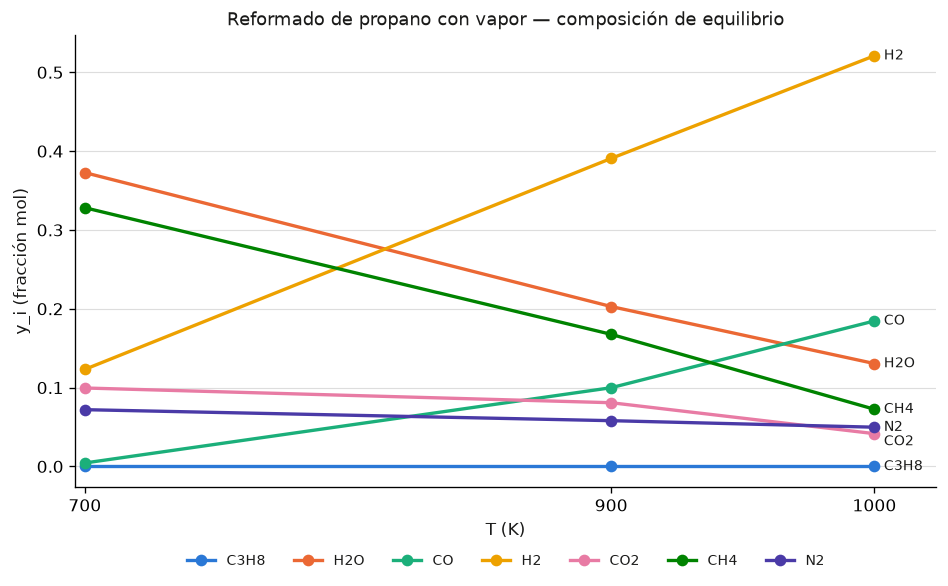

In [5]:
_PALETA = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",   # misma paleta que core/exercise.py
           "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
_TINTA = "#1a1a19"

temps = sorted(casos)
fig, ax = plt.subplots(figsize=(8.0, 5.0), dpi=120)
for k, sp in enumerate(especies):
    ax.plot(temps, [tabla.loc[T, f"y_{sp}"] for T in temps], color=_PALETA[k], lw=2, marker="o", ms=6, label=sp)
y_fin = sorted(((tabla.loc[temps[-1], f"y_{sp}"], sp) for sp in especies), reverse=True)
sep, y_prev = 0.035 * (y_fin[0][0] - y_fin[-1][0]), None
dx = 0.012 * (temps[-1] - temps[0])
for v, sp in y_fin:
    y_lab = v if y_prev is None else min(v, y_prev - sep)
    ax.annotate(sp, (temps[-1], v), xytext=(temps[-1] + dx, y_lab), fontsize=8.5, color=_TINTA, va="center")
    y_prev = y_lab
ax.set_xlabel("T (K)", color=_TINTA); ax.set_ylabel("y_i (fracción mol)", color=_TINTA)
ax.set_title("Reformado de propano con vapor — composición de equilibrio", color=_TINTA, fontsize=11)
ax.set_xticks(temps); ax.set_xlim(temps[0] - dx, temps[-1] + 6.5 * dx)
ax.grid(axis="y", color="#dddddd", lw=0.7)
for lado in ("top", "right"):
    ax.spines[lado].set_visible(False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=len(especies), frameon=False, fontsize=8.5, labelcolor=_TINTA)
fig.tight_layout()
plt.show()

## Verificación contra la clave del profesor

Tolerancia relativa 1e-4 por valor (la misma que usa `ej2_mio.py`).

In [6]:
TOL_CLAVE = 1e-4
clave_xi = {700: (0.24044, 0.69089, 0.75956), 900: (0.51886, 0.69625, 0.48114), 1000: (0.75718, 0.41774, 0.24282)}
clave_metricas = {   # T: (S_CO, S_CO2, S_CH4, Y_H2, H2_CO, H2_COx)
    700:  (0.010139, 0.2303,  0.75956, 0.085482, 28.105, 1.1851),
    900:  (0.28677,  0.23208, 0.48114, 0.33659,  3.9124, 2.1624),
    1000: (0.61794,  0.13925, 0.24282, 0.52324,  2.8225, 2.3034),
}
comp = []
for T in temps:
    calc = list(resultados[T].xi) + [tabla_metricas.loc[T, m] for m in ("S_CO", "S_CO2", "S_CH4", "Y_H2", "H2_CO", "H2_COx")]
    ref = list(clave_xi[T]) + list(clave_metricas[T])
    for nombre, c_, r_ in zip(("xi_1", "xi_2", "xi_3", "S_CO", "S_CO2", "S_CH4", "Y_H2", "H2_CO", "H2_COx"), calc, ref):
        comp.append({"T (K)": T, "valor": nombre, "calc": c_, "clave": r_, "dif. rel.": abs(c_ - r_) / abs(r_),
                     "PASS": abs(c_ - r_) / abs(r_) < TOL_CLAVE})
comparacion = pd.DataFrame(comp)
n_pass = int(comparacion["PASS"].sum())
print(f"Clave del profesor: {n_pass}/{len(comparacion)} PASS")
assert n_pass == len(comparacion), "hay valores fuera de tolerancia"
comparacion.style.format({"calc": "{:.5f}", "clave": "{:.5f}", "dif. rel.": "{:.1e}"})

Clave del profesor: 27/27 PASS


,T (K),valor,calc,clave,dif. rel.,PASS
0,700,xi_1,0.24044,0.24044,1.5e-05,True
1,700,xi_2,0.69089,0.69089,4.8e-06,True
2,700,xi_3,0.75956,0.75956,4.8e-06,True
3,700,S_CO,0.01014,0.01014,4.4e-05,True
4,700,S_CO2,0.23030,0.23030,9.7e-06,True
5,700,S_CH4,0.75956,0.75956,4.8e-06,True
6,700,Y_H2,0.08548,0.08548,3.9e-07,True
7,700,H2_CO,28.10460,28.10500,1.4e-05,True
8,700,H2_COx,1.18510,1.18510,3.5e-06,True
9,900,xi_1,0.51885,0.51886,9.7e-06,True


## Autovalidación (selfcheck)

Los 12 puntos por temperatura (puntos 1–10 y 12) y el chequeo de Le Chatelier del barrido
(punto 11), exactamente como los corre el script canónico.

In [7]:
reportes = {}
for T, K in casos.items():
    problema = Problem(species=especies, n0=n0, nu=nu, K=K, P=P, P0=1.0, atoms=atomos,
                       inerts=["N2"], T=T, pressure_unit="bar", label="Reformado de propano")
    reportes[T] = validate(problema, resultados[T])
reporte_barrido = validate_sweep(casos, {T: tuple(r.xi) for T, r in resultados.items()})

assert all(r.ok for r in reportes.values()) and reporte_barrido.ok
print(f"\nSelfcheck: {len(reportes)} reportes por T + barrido, todos sin FAIL")


  --------------------------------------------------------------
  AUTOVALIDACIÓN (selfcheck.validate) — Reformado de propano, T = 700 K
  --------------------------------------------------------------
  Sanidad de la entrada:
    [PASS]  1. balance de elementos (C, H, N, O): R1..R3 balanceadas
    [PASS]  2. columna nula en nu: N2 — declarada(s) inerte(s), consistente
    [PASS]  3. número de K (3) == número de reacciones (3)
    [info]  4. delta_j:  R1: +6,  R2: +0,  R3: +0
               n_T = 5.5 + 6·xi_1
    [info]  5. K1 = y_CO^3 y_H2^7 / (y_C3H8 y_H2O^3) * (P/P0)^6
               K2 = y_H2 y_CO2 / (y_H2O y_CO)
               K3 = y_CH4^3 / (y_C3H8 y_H2^2)
  Calidad de la solución:
    [PASS]  6. residuos |K_calc-K|/K: [2.4e-08, 1.3e-12, 2.4e-08]  (máx = 2.4e-08 < 1e-06)
    [PASS]  7. átomos in vs out: máx |Δ| = 0.0e+00 mol  (C: 3 -> 3, H: 16 -> 16, N: 1 -> 1, O: 4 -> 4)
               n_i >= 0: mín n_i = 6.69e-10 mol
               sum y_i = 1.000000000000
    [PASS]  8. robus